In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/burnoutminer/heights-and-weights-dataset/SOCR-HeightWeight.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('/kaggle/input/datasets/burnoutminer/heights-and-weights-dataset/SOCR-HeightWeight.csv')

In [4]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [5]:
df.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


In [6]:
df.shape

(25000, 3)

<Axes: ylabel='Height(Inches)'>

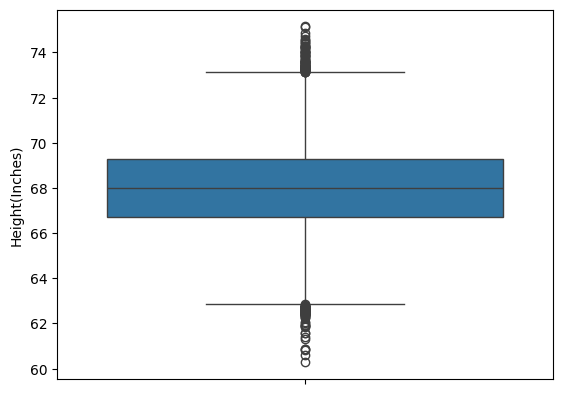

In [7]:
sns.boxplot(df['Height(Inches)'])

/tmp/ipykernel_16/2122790197.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height(Inches)'])


<Axes: xlabel='Height(Inches)', ylabel='Density'>

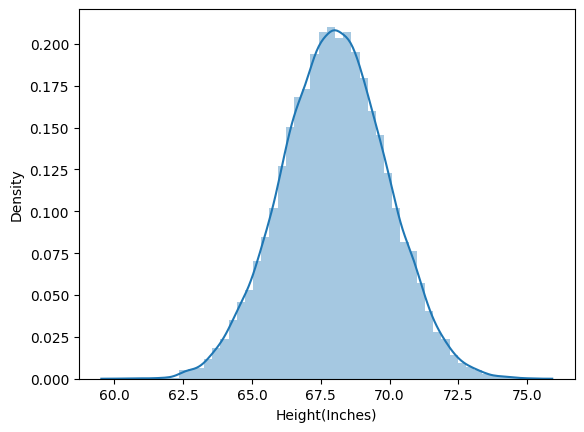

In [8]:
sns.distplot(df['Height(Inches)'])

/tmp/ipykernel_16/3598723887.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight(Pounds)'])


<Axes: xlabel='Weight(Pounds)', ylabel='Density'>

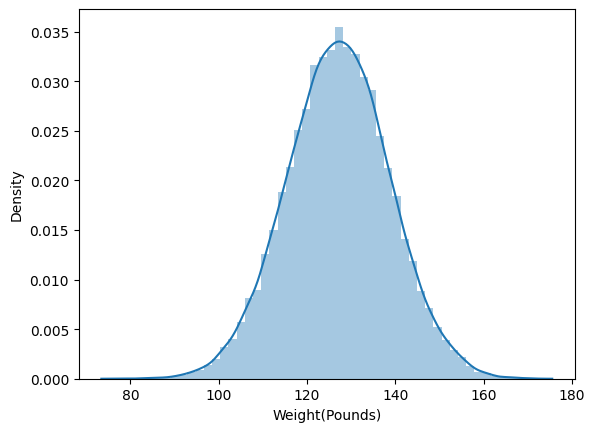

In [9]:
sns.distplot(df['Weight(Pounds)'])

<Axes: ylabel='Weight(Pounds)'>

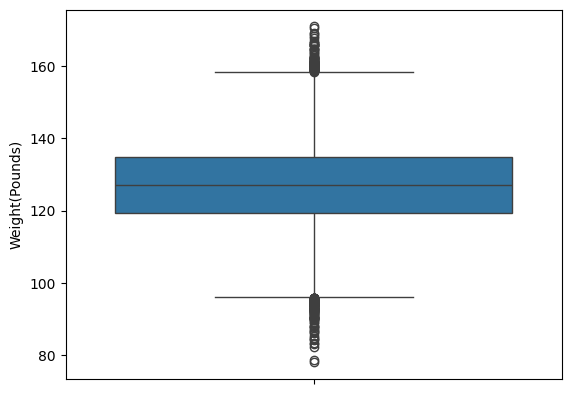

In [10]:
sns.boxplot(df['Weight(Pounds)'])

# Weight(Pounds)

In [11]:
maximum = df['Weight(Pounds)'].quantile(0.99)
minimum = df['Weight(Pounds)'].quantile(0.1)

In [12]:
maximum

np.float64(154.316722)

In [13]:
minimum

np.float64(112.10983999999999)

In [14]:
df['Weight(Pounds)'].describe()

count    25000.000000
mean       127.079421
std         11.660898
min         78.014760
25%        119.308675
50%        127.157750
75%        134.892850
max        170.924000
Name: Weight(Pounds), dtype: float64

# Trimming

In [15]:
df[df['Weight(Pounds)']>maximum]

,Index,Height(Inches),Weight(Pounds)
56,57,70.40617,155.8987
82,83,70.05147,155.3767
156,157,70.98112,158.9562
209,210,71.55542,155.9414
287,288,69.93715,155.3046
...,...,...,...
24750,24751,70.82192,159.6344
24889,24890,71.01048,161.8532
24926,24927,71.69485,154.4811
24947,24948,69.17056,154.7821


In [16]:
df[df['Weight(Pounds)']<minimum]

,Index,Height(Inches),Weight(Pounds)
22,23,63.48115,97.90191
28,29,66.53401,108.33240
30,31,69.52330,103.30160
39,40,64.04535,106.71150
44,45,65.98088,106.44990
...,...,...,...
24960,24961,68.92465,106.30210
24977,24978,67.24989,108.71780
24981,24982,66.30104,107.39010
24983,24984,63.77967,111.49110


In [17]:
new_df=df[(df['Weight(Pounds)']<=maximum) & (df['Weight(Pounds)']>=minimum)]

/tmp/ipykernel_16/2881611663.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight(Pounds)'])
/tmp/ipykernel_16/2881611663.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Weight(Pounds)'])


<Axes: ylabel='Weight(Pounds)'>

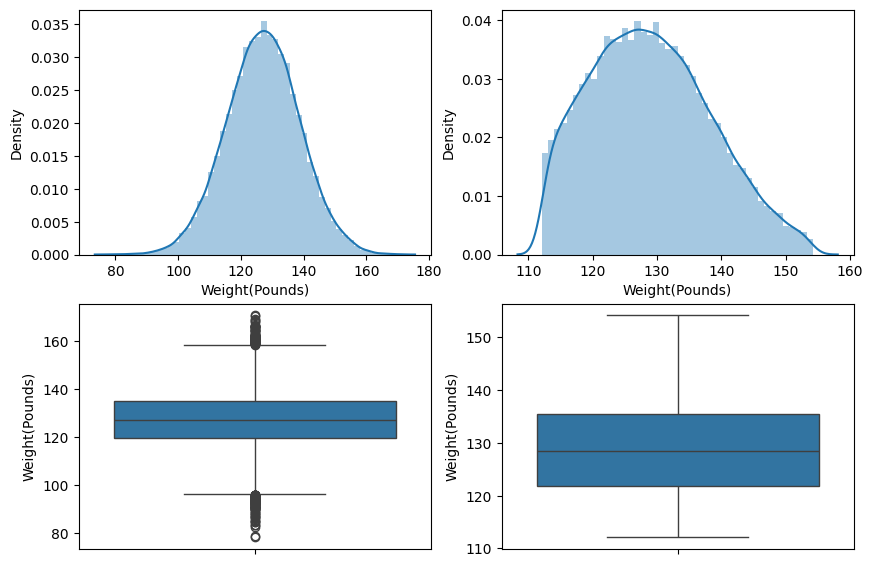

In [18]:
plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
sns.distplot(df['Weight(Pounds)'])

plt.subplot(2,2,2)
sns.distplot(new_df['Weight(Pounds)'])

plt.subplot(2,2,3)
sns.boxplot(df['Weight(Pounds)'])

plt.subplot(2,2,4)
sns.boxplot(new_df['Weight(Pounds)'])

In [19]:
new_df.shape

(22250, 3)

# Capping

In [20]:
new_cap_df=df.copy()

new_cap_df['Weight(Pounds)']=np.where(df['Weight(Pounds)']>maximum,maximum,
        np.where(df['Weight(Pounds)']<minimum,minimum,
                df['Weight(Pounds)']))

In [21]:
df.shape

(25000, 3)

/tmp/ipykernel_16/2165522205.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight(Pounds)'])
/tmp/ipykernel_16/2165522205.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_cap_df['Weight(Pounds)'])


<Axes: ylabel='Weight(Pounds)'>

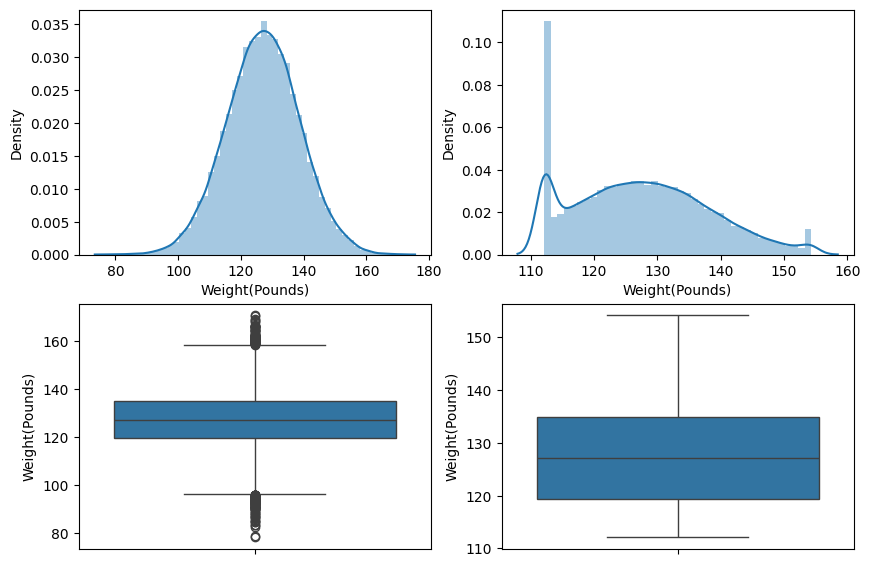

In [22]:
plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
sns.distplot(df['Weight(Pounds)'])

plt.subplot(2,2,2)
sns.distplot(new_cap_df['Weight(Pounds)'])

plt.subplot(2,2,3)
sns.boxplot(df['Weight(Pounds)'])

plt.subplot(2,2,4)
sns.boxplot(new_cap_df['Weight(Pounds)'])

In [23]:
new_cap_df['Weight(Pounds)'].describe()

count    25000.000000
mean       127.607106
std         10.532761
min        112.109840
25%        119.308675
50%        127.157750
75%        134.892850
max        154.316722
Name: Weight(Pounds), dtype: float64

In [24]:
df['Weight(Pounds)'].describe()

count    25000.000000
mean       127.079421
std         11.660898
min         78.014760
25%        119.308675
50%        127.157750
75%        134.892850
max        170.924000
Name: Weight(Pounds), dtype: float64

### Choose percentile methos when your data is skewed in this our data has normally distributed so it not perform well